# Report-like waterfall notebook prototype

Questo notebook parte dai dataset semantici in `fin_pipeline` e costruisce visualizzazioni **waterfall** allineate alle famiglie di insight del PPT `2026-02_Internal Sales_February2026.pptx`.

Obiettivo pratico:
- validare che il layer semantico supporti le stesse letture del report manuale
- usare waterfall chart per BU, regioni, countries, products e area pages
- preparare una base locale prima di pensare a una dashboard Databricks

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 10

cwd = Path.cwd()
BASE_DIR = cwd if cwd.name == "fin_pipeline" else cwd / "fin_pipeline"
SOURCE_KIND = "canonical"   # "canonical" oppure "final"
TOP_N = 10
EXPORT_FIGURES = False
EXPORT_DIR = BASE_DIR / "waterfall_exports"

print("BASE_DIR:", BASE_DIR)
print("SOURCE_KIND:", SOURCE_KIND)

BASE_DIR: c:\work\MEN_Marketing\04_PRG_20251111___OCR_Sys_perlettura_PDF\PDFDataExtractor-pipeline\fin_pipeline
SOURCE_KIND: canonical


In [2]:
SOURCE_DIRS = {
    "canonical": BASE_DIR / "evoluzione_dei_data_source_partendo_da_sorgente_tidy",
    "final": BASE_DIR / "evoluzione_dei_data_source_partendo_da_sorgente_wide",
}

FILE_MAP = {
    "canonical": {
        "overview": "gold_overview.csv",
        "moves": "gold_country_product_moves.csv",
        "area": "gold_area_products.csv",
        "business": "silver_business_fact.csv",
        "semantic": "silver_semantic_long.csv",
    },
    "final": {
        "overview": "gold_overview_from_final.csv",
        "moves": "gold_country_product_moves_from_final.csv",
        "area": "gold_area_products_from_final.csv",
        "business": "silver_business_fact_from_final.csv",
        "semantic": "silver_semantic_long_from_final.csv",
    },
}

def _read_csv_if_exists(path: Path):
    return pd.read_csv(path) if path.exists() else None

source_dir = SOURCE_DIRS[SOURCE_KIND]
paths = {name: source_dir / filename for name, filename in FILE_MAP[SOURCE_KIND].items()}

overview_df = _read_csv_if_exists(paths["overview"])
moves_df = _read_csv_if_exists(paths["moves"])
area_df = _read_csv_if_exists(paths["area"])
business_df = _read_csv_if_exists(paths["business"])
semantic_df = _read_csv_if_exists(paths["semantic"])

for name, df in {
    "overview": overview_df,
    "moves": moves_df,
    "area": area_df,
    "business": business_df,
    "semantic": semantic_df,
}.items():
    print(f"{name:8s} ->", None if df is None else df.shape)

if overview_df is None or moves_df is None:
    raise FileNotFoundError("Missing required overview/moves datasets for waterfall notebook.")

overview -> (108, 16)
moves    -> (176, 14)
area     -> (2200, 16)
business -> (1825, 28)
semantic -> (3423, 25)


In [3]:
def ensure_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def fmt_mio(x: float) -> str:
    if pd.isna(x):
        return "—"
    return f"{x / 1000:,.1f}"


def prepare_waterfall(
    df: pd.DataFrame,
    label_col: str = "entity_label",
    actual_col: str = "actual_value",
    base_col: str = "base_value",
    variance_col: str = "variance_abs",
    total_label_candidates: tuple[str, ...] = ("TOTAL", "TOTAL GROUP", "PHARMA"),
    top_n: int | None = None,
) -> tuple[pd.DataFrame, float, float, float]:
    data = ensure_numeric(df.copy(), [actual_col, base_col, variance_col])
    data[label_col] = data[label_col].astype("string").str.strip()
    data = data[data[label_col].notna() & data[variance_col].notna()].copy()

    total_mask = data[label_col].str.upper().isin([x.upper() for x in total_label_candidates])

    total_row = data.loc[total_mask].head(1)
    if not total_row.empty:
        base_value = float(total_row[base_col].iloc[0]) if pd.notna(total_row[base_col].iloc[0]) else np.nan
        actual_value = float(total_row[actual_col].iloc[0]) if pd.notna(total_row[actual_col].iloc[0]) else np.nan
        total_delta = float(total_row[variance_col].iloc[0])
        components = data.loc[~total_mask].copy()
    else:
        components = data.copy()
        base_value = float(components[base_col].sum(skipna=True)) if base_col in components.columns else np.nan
        actual_value = float(components[actual_col].sum(skipna=True)) if actual_col in components.columns else np.nan
        total_delta = float(components[variance_col].sum(skipna=True))

    components = (
        components.groupby(label_col, dropna=False, as_index=False)[variance_col]
        .sum()
        .rename(columns={variance_col: "delta_value"})
    )
    components = components[components[label_col].notna()].copy()
    components["abs_delta"] = components["delta_value"].abs()
    components = components.sort_values(["abs_delta", label_col], ascending=[False, True]).reset_index(drop=True)

    if top_n is not None and len(components) > top_n:
        selected = components.head(top_n).copy()
        residual = total_delta - selected["delta_value"].sum()
        if abs(residual) > 1e-9:
            selected.loc[len(selected)] = {
                label_col: "OTHER / RESIDUAL",
                "delta_value": residual,
                "abs_delta": abs(residual),
            }
        components = selected

    steps = []
    running = 0.0 if pd.isna(base_value) else base_value

    if pd.notna(base_value):
        steps.append({
            "label": "BASE",
            "kind": "base",
            "display_value": base_value,
            "bar_bottom": 0.0,
            "bar_height": base_value,
            "color": "#4C78A8",
        })

    for _, row in components.iterrows():
        delta = float(row["delta_value"])
        bottom = running if delta >= 0 else running + delta
        steps.append({
            "label": row[label_col],
            "kind": "change",
            "display_value": delta,
            "bar_bottom": bottom,
            "bar_height": abs(delta),
            "color": "#54A24B" if delta >= 0 else "#E45756",
        })
        running += delta

    final_value = actual_value if pd.notna(actual_value) else running
    steps.append({
        "label": "ACTUAL",
        "kind": "final",
        "display_value": final_value,
        "bar_bottom": 0.0,
        "bar_height": final_value,
        "color": "#4C78A8",
    })

    return pd.DataFrame(steps), base_value, final_value, total_delta


def plot_waterfall(ax, wf: pd.DataFrame, title: str, subtitle: str = "") -> None:
    x = np.arange(len(wf))
    ax.bar(x, wf["bar_height"] / 1000, bottom=wf["bar_bottom"] / 1000, color=wf["color"], width=0.72)

    for i, row in wf.iterrows():
        y = (row["bar_bottom"] + row["bar_height"]) / 1000
        ax.text(i, y, fmt_mio(row["display_value"]), ha="center", va="bottom", fontsize=9)

    for i in range(len(wf) - 2):
        current = wf.iloc[i]
        nxt = wf.iloc[i + 1]
        line_y = (current["bar_bottom"] + current["bar_height"]) / 1000 if current["kind"] != "change" or current["display_value"] >= 0 else current["bar_bottom"] / 1000
        next_anchor = nxt["bar_bottom"] / 1000 if nxt["kind"] == "change" else (nxt["bar_bottom"] + nxt["bar_height"]) / 1000
        ax.plot([i + 0.36, i + 0.64], [line_y, next_anchor], color="#9AA1A9", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(wf["label"], rotation=35, ha="right")
    ax.set_ylabel("EUR mio")
    ax.set_title(title)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, fontsize=10, color="#555555")
    ax.axhline(0, color="#666666", linewidth=1)
    ax.grid(axis="y", alpha=0.25)


def render_pair(df: pd.DataFrame, left_cfg: dict, right_cfg: dict, fig_title: str):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
    for ax, cfg in zip(axes, [left_cfg, right_cfg]):
        subset = df.copy()
        for col, val in cfg["filters"].items():
            subset = subset[subset[col] == val]
        wf, base, actual, total_delta = prepare_waterfall(
            subset,
            label_col=cfg.get("label_col", "entity_label"),
            actual_col=cfg.get("actual_col", "actual_value"),
            base_col=cfg.get("base_col", "base_value"),
            variance_col=cfg.get("variance_col", "variance_abs"),
            total_label_candidates=cfg.get("total_label_candidates", ("TOTAL", "TOTAL GROUP", "PHARMA")),
            top_n=cfg.get("top_n", TOP_N),
        )
        subtitle = f"Base {fmt_mio(base)} | Actual {fmt_mio(actual)} | Delta {fmt_mio(total_delta)}"
        plot_waterfall(ax, wf, cfg["title"], subtitle)

    fig.suptitle(fig_title, fontsize=16, fontweight="bold")
    return fig


def maybe_export(fig, filename: str):
    if not EXPORT_FIGURES:
        return
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    path = EXPORT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)

## Slide family 1: Group overview

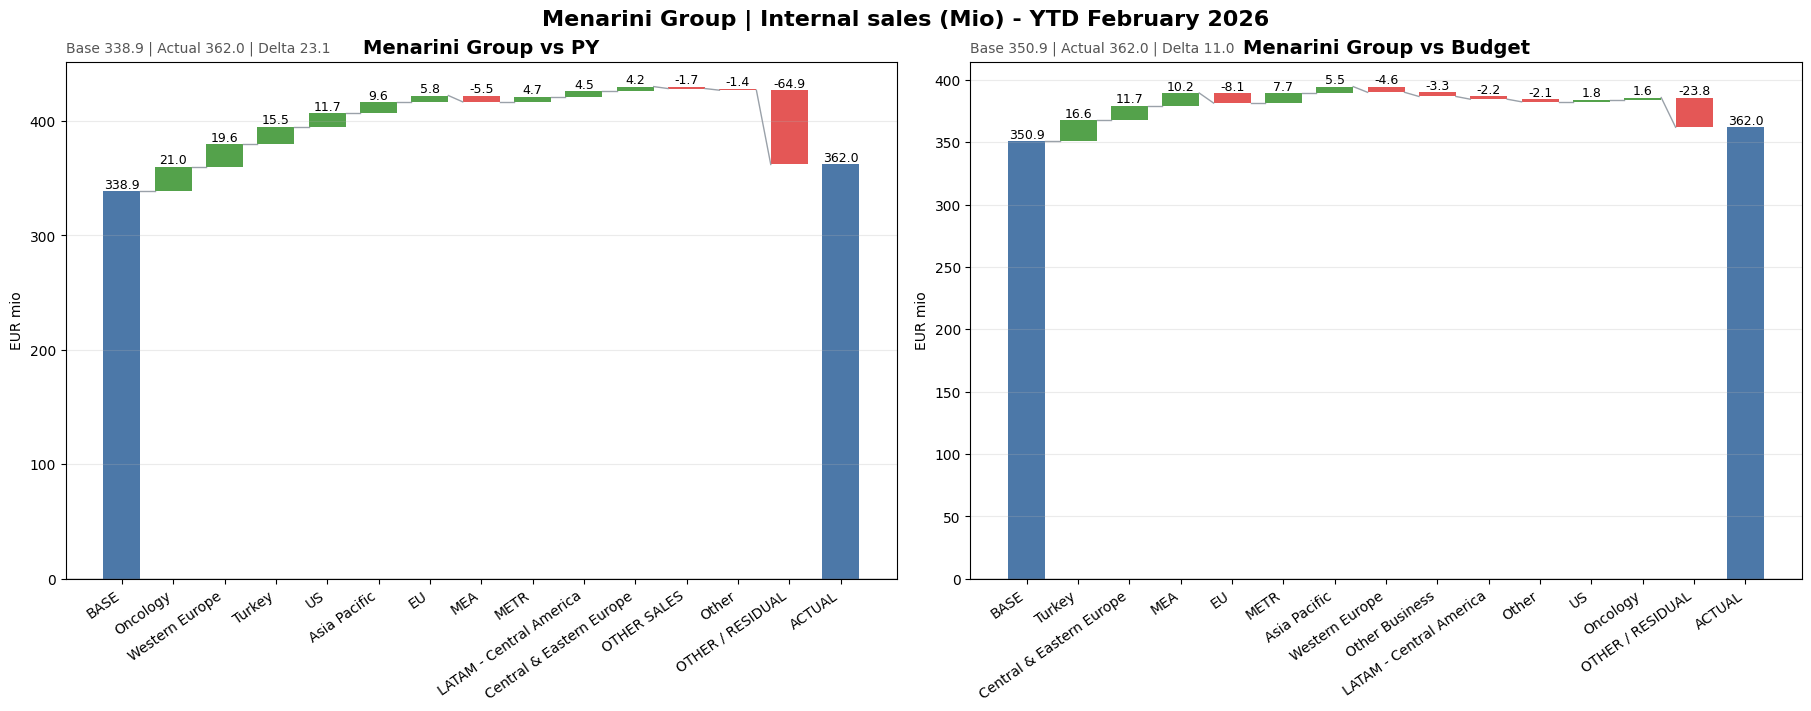

In [4]:
overview_df = ensure_numeric(
    overview_df,
    ["actual_value", "budget_value", "py_actual_value", "variance_vs_budget_abs", "variance_vs_py_abs"],
)

group_overview = overview_df[
    (overview_df["section_family"] == "GROUP_OVERVIEW") &
    (overview_df["page_title"] == "MENARINI GROUP OVERVIEW")
].copy()

fig = render_pair(
    group_overview,
    left_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "py_actual_value",
        "variance_col": "variance_vs_py_abs",
        "title": "Menarini Group vs PY",
        "top_n": 12,
    },
    right_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "budget_value",
        "variance_col": "variance_vs_budget_abs",
        "title": "Menarini Group vs Budget",
        "top_n": 12,
    },
    fig_title="Menarini Group | Internal sales (Mio) - YTD February 2026",
)
maybe_export(fig, "01_group_overview_waterfall.png")
plt.show()

## Slide family 2: Business units and regions

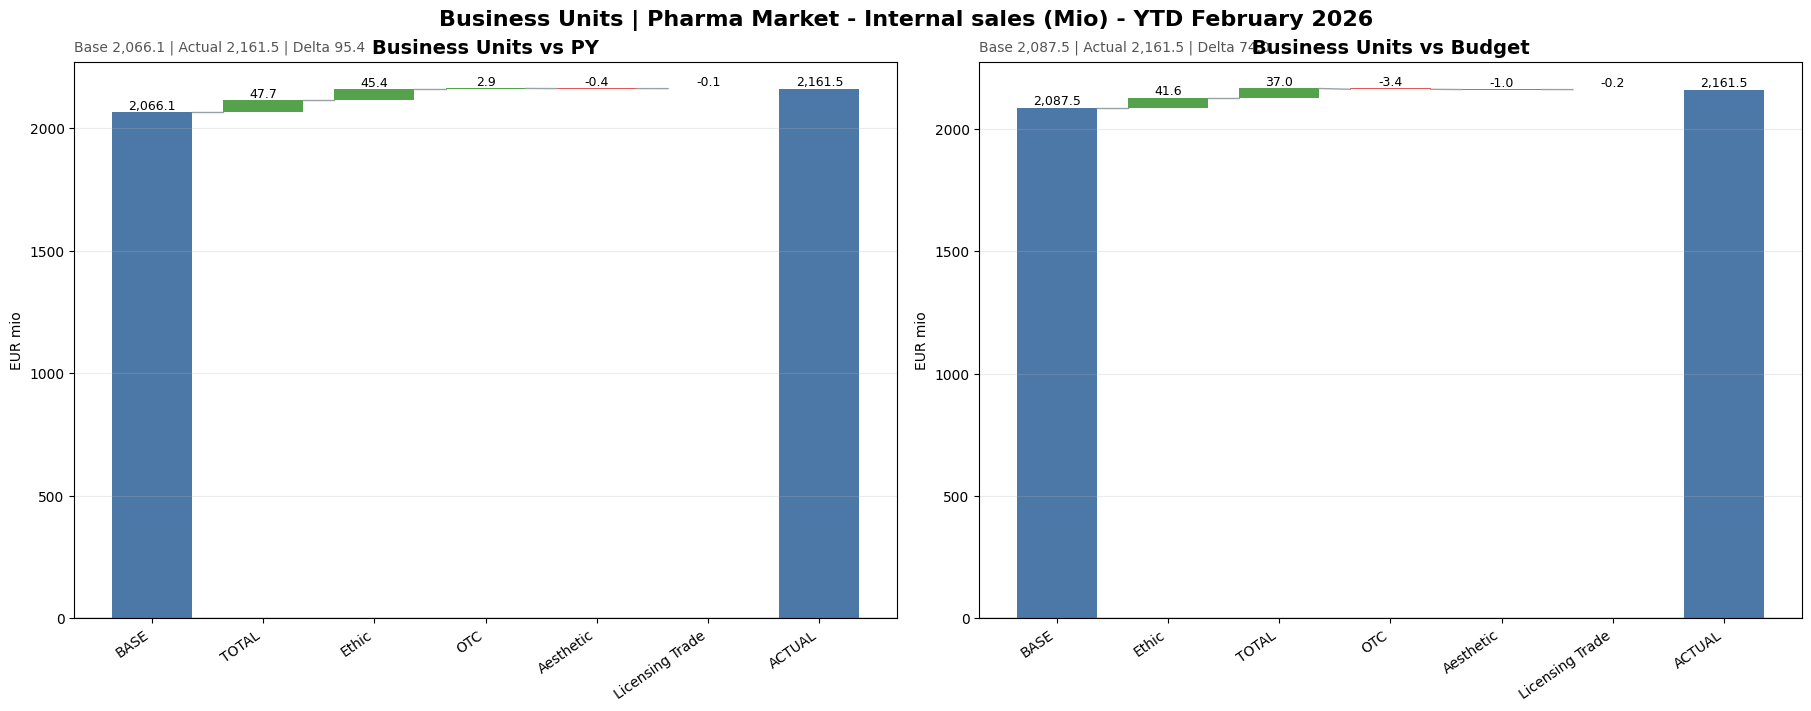

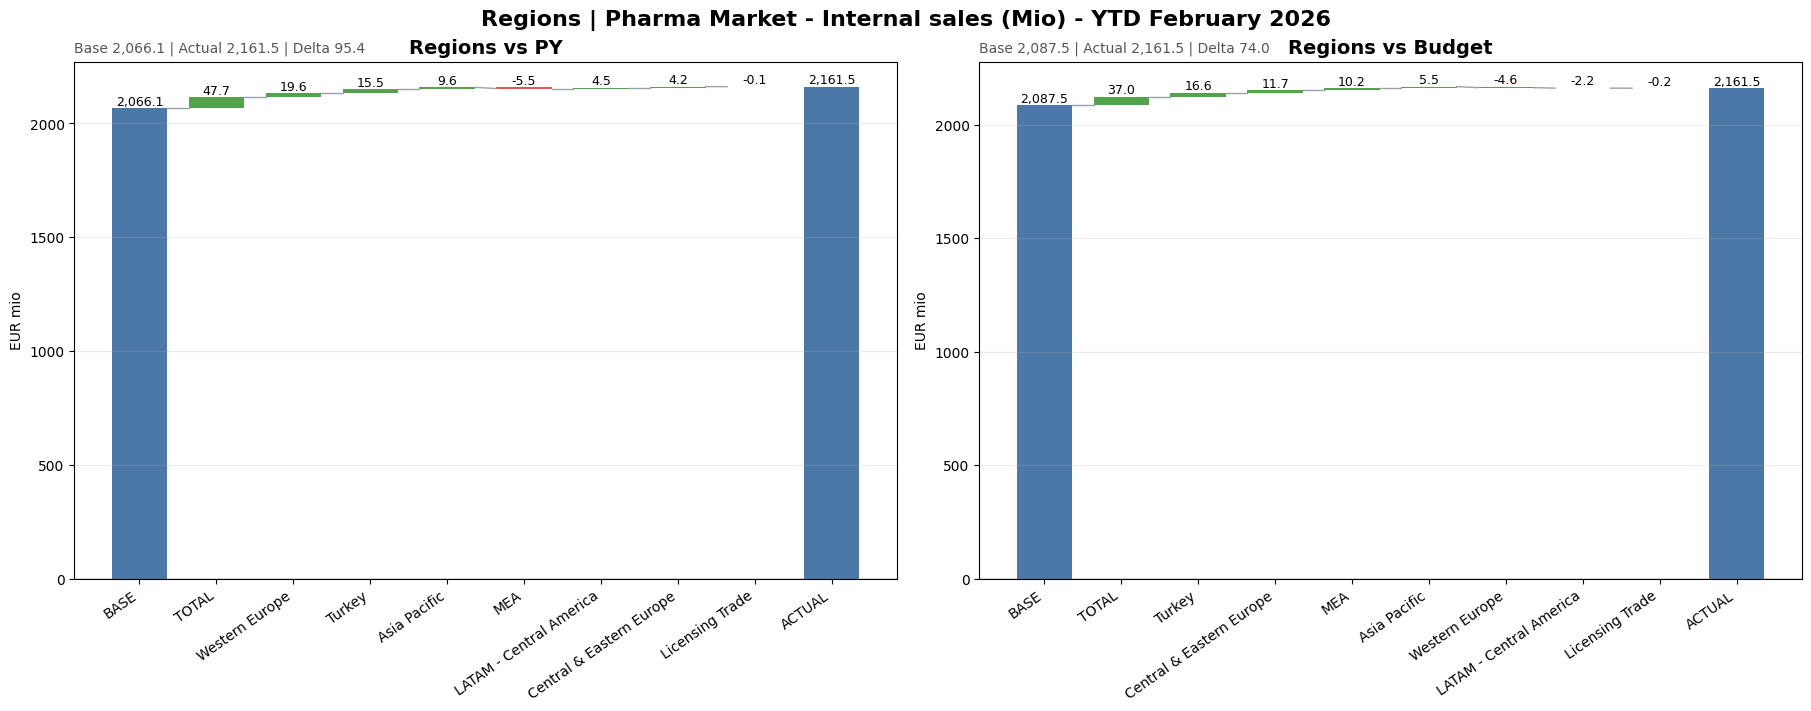

In [5]:
bu_df = overview_df[overview_df["section_family"] == "BU"].copy()
region_df = overview_df[overview_df["section_family"] == "REGION"].copy()

fig_bu = render_pair(
    bu_df,
    left_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "py_actual_value",
        "variance_col": "variance_vs_py_abs",
        "title": "Business Units vs PY",
        "top_n": None,
        "total_label_candidates": tuple(),
    },
    right_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "budget_value",
        "variance_col": "variance_vs_budget_abs",
        "title": "Business Units vs Budget",
        "top_n": None,
        "total_label_candidates": tuple(),
    },
    fig_title="Business Units | Pharma Market - Internal sales (Mio) - YTD February 2026",
)
maybe_export(fig_bu, "02_business_units_waterfall.png")
plt.show()

fig_region = render_pair(
    region_df,
    left_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "py_actual_value",
        "variance_col": "variance_vs_py_abs",
        "title": "Regions vs PY",
        "top_n": None,
        "total_label_candidates": tuple(),
    },
    right_cfg={
        "filters": {},
        "actual_col": "actual_value",
        "base_col": "budget_value",
        "variance_col": "variance_vs_budget_abs",
        "title": "Regions vs Budget",
        "top_n": None,
        "total_label_candidates": tuple(),
    },
    fig_title="Regions | Pharma Market - Internal sales (Mio) - YTD February 2026",
)
maybe_export(fig_region, "03_regions_waterfall.png")
plt.show()

## Slide family 3: Country and product movers

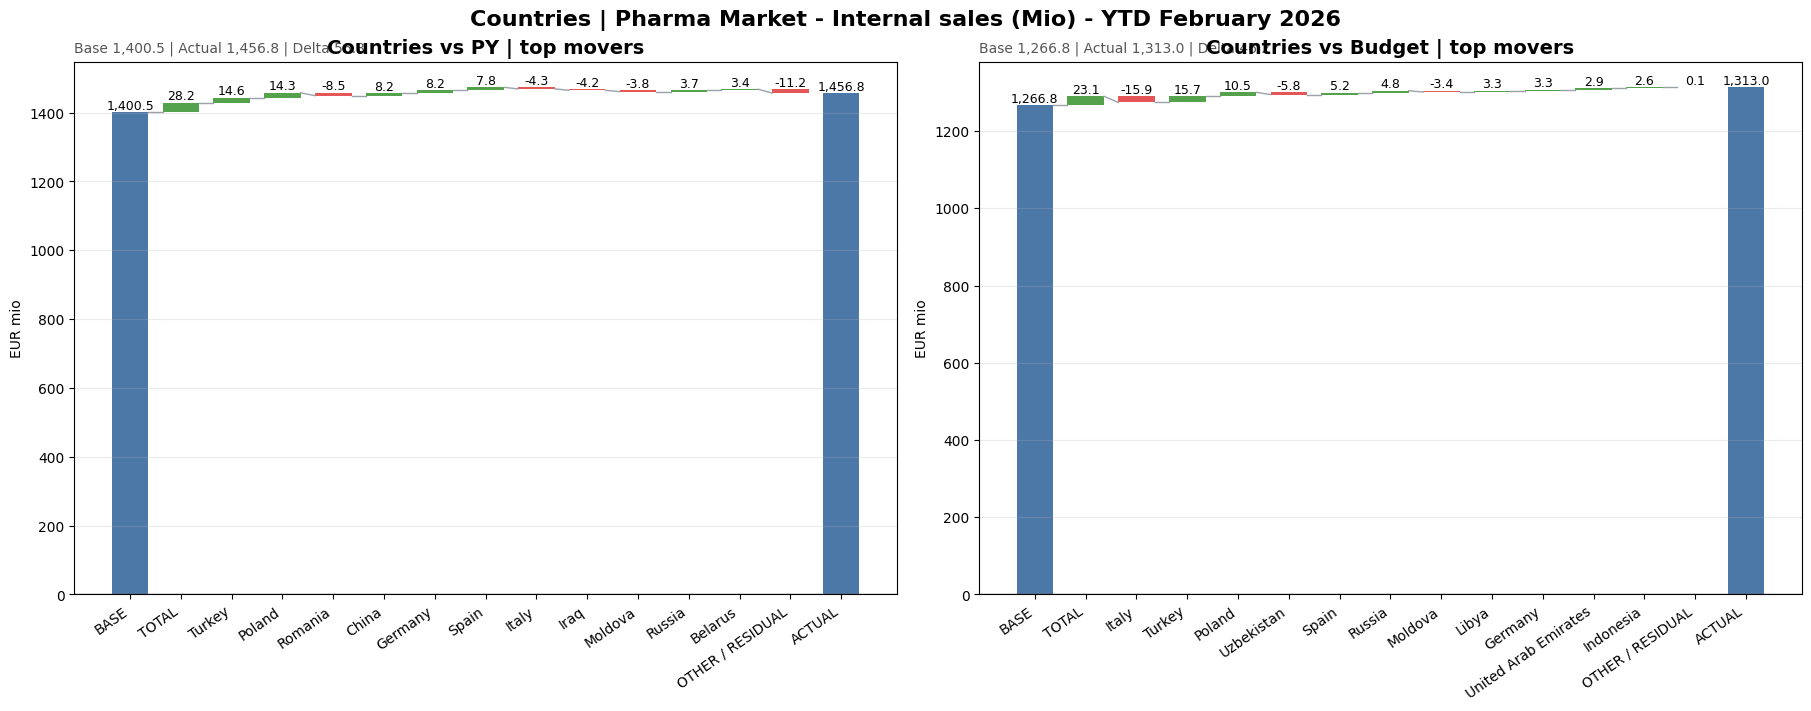

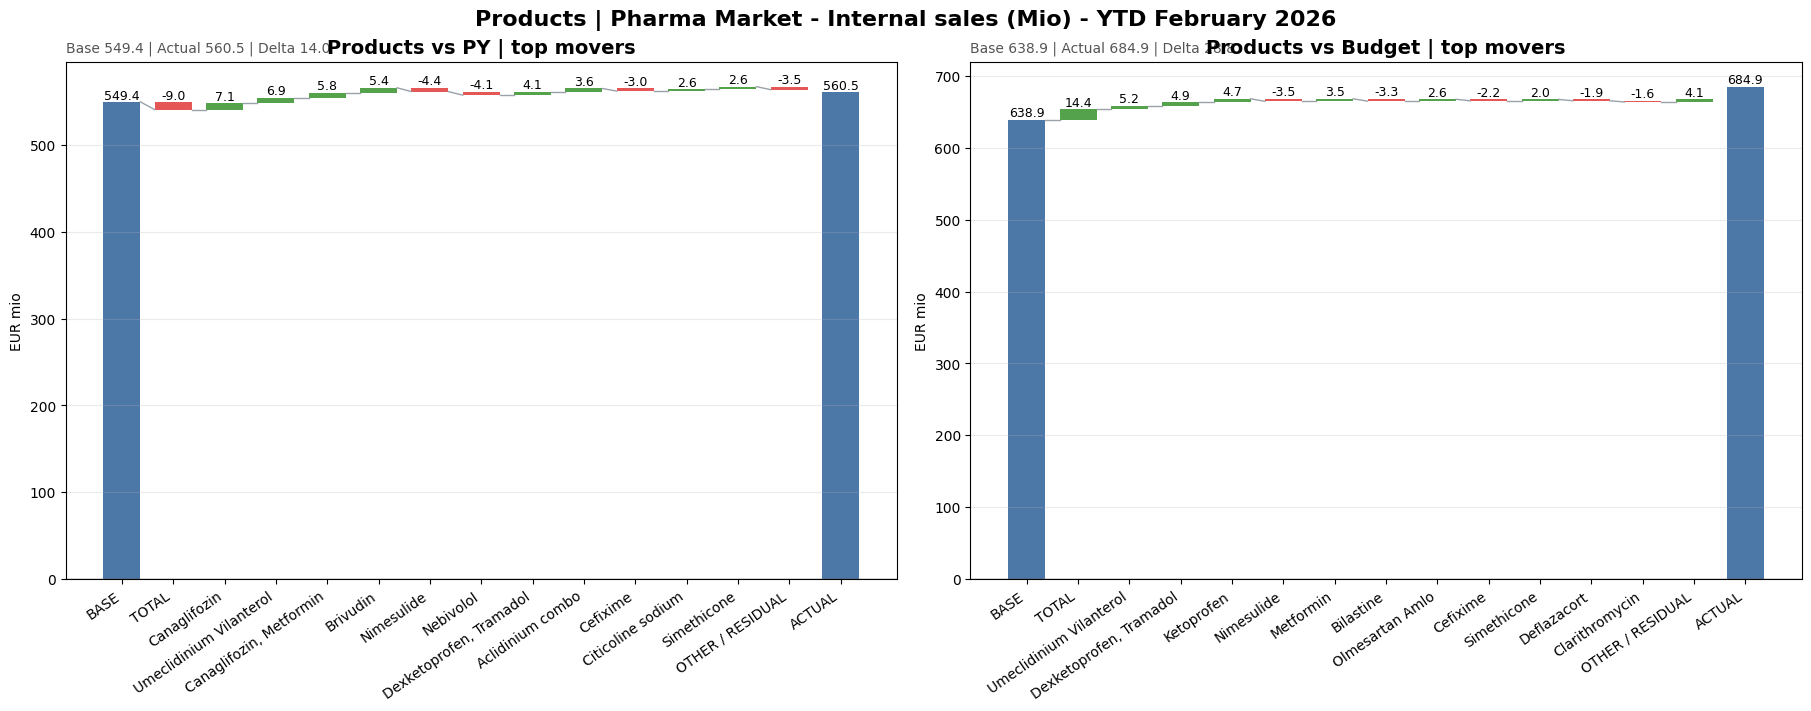

In [6]:
moves_df = ensure_numeric(moves_df, ["actual_value", "base_value", "variance_abs", "variance_pct"])

country_df = moves_df[moves_df["section_family"] == "COUNTRY_DEVIATION"].copy()
product_df = moves_df[moves_df["section_family"] == "PRODUCT_DEVIATION"].copy()

fig_country = render_pair(
    country_df,
    left_cfg={
        "filters": {"comparison_type": "PY"},
        "title": "Countries vs PY | top movers",
        "top_n": 12,
        "total_label_candidates": tuple(),
    },
    right_cfg={
        "filters": {"comparison_type": "BDG"},
        "title": "Countries vs Budget | top movers",
        "top_n": 12,
        "total_label_candidates": tuple(),
    },
    fig_title="Countries | Pharma Market - Internal sales (Mio) - YTD February 2026",
)
maybe_export(fig_country, "04_country_movers_waterfall.png")
plt.show()

fig_product = render_pair(
    product_df,
    left_cfg={
        "filters": {"comparison_type": "PY"},
        "title": "Products vs PY | top movers",
        "top_n": 12,
        "total_label_candidates": tuple(),
    },
    right_cfg={
        "filters": {"comparison_type": "BDG"},
        "title": "Products vs Budget | top movers",
        "top_n": 12,
        "total_label_candidates": tuple(),
    },
    fig_title="Products | Pharma Market - Internal sales (Mio) - YTD February 2026",
)
maybe_export(fig_product, "05_product_movers_waterfall.png")
plt.show()

## Slide family 4: Area product pages

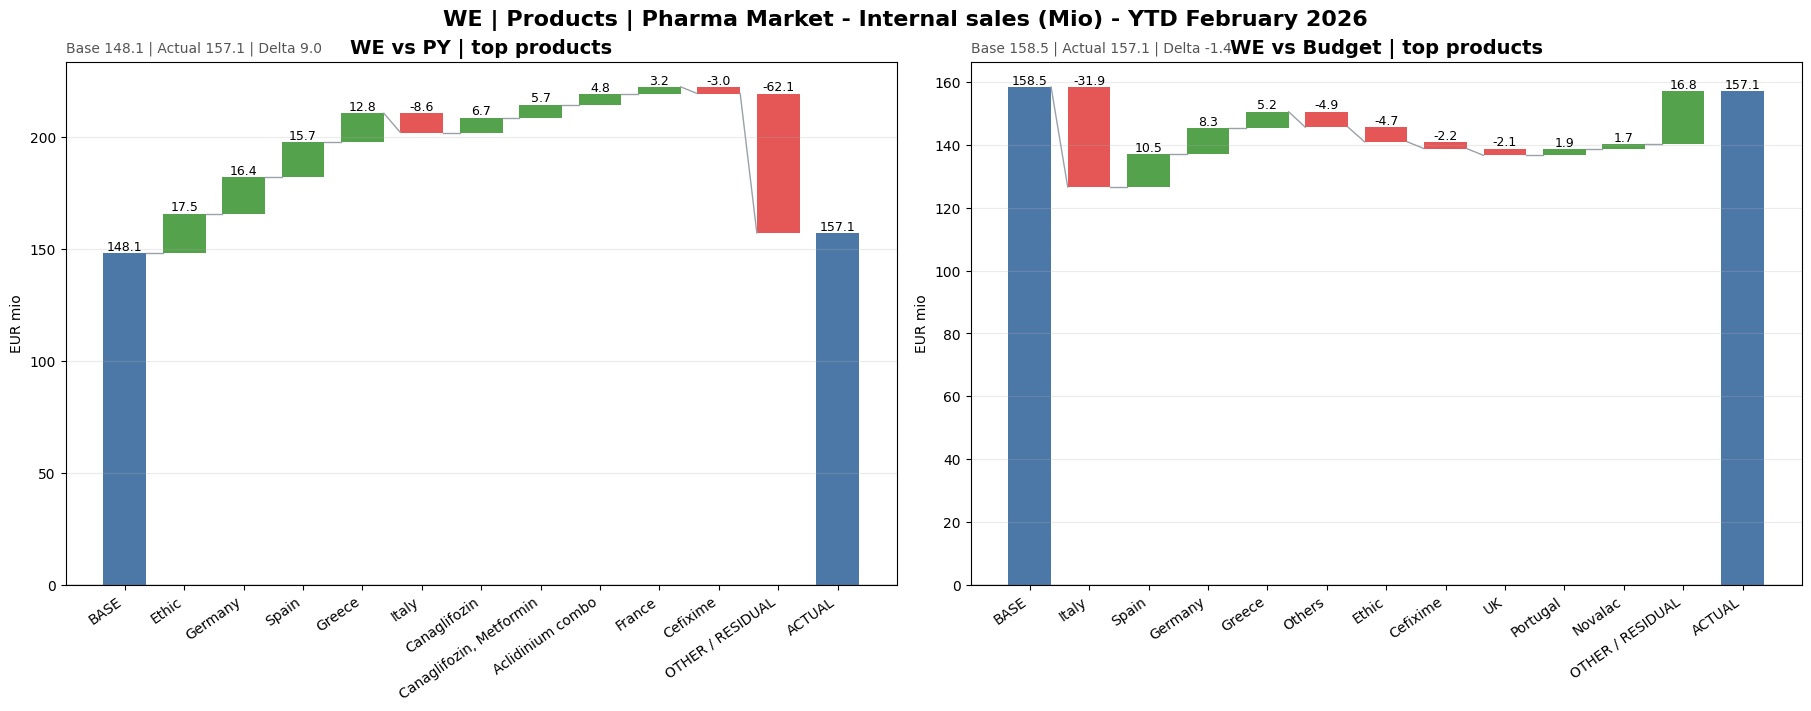

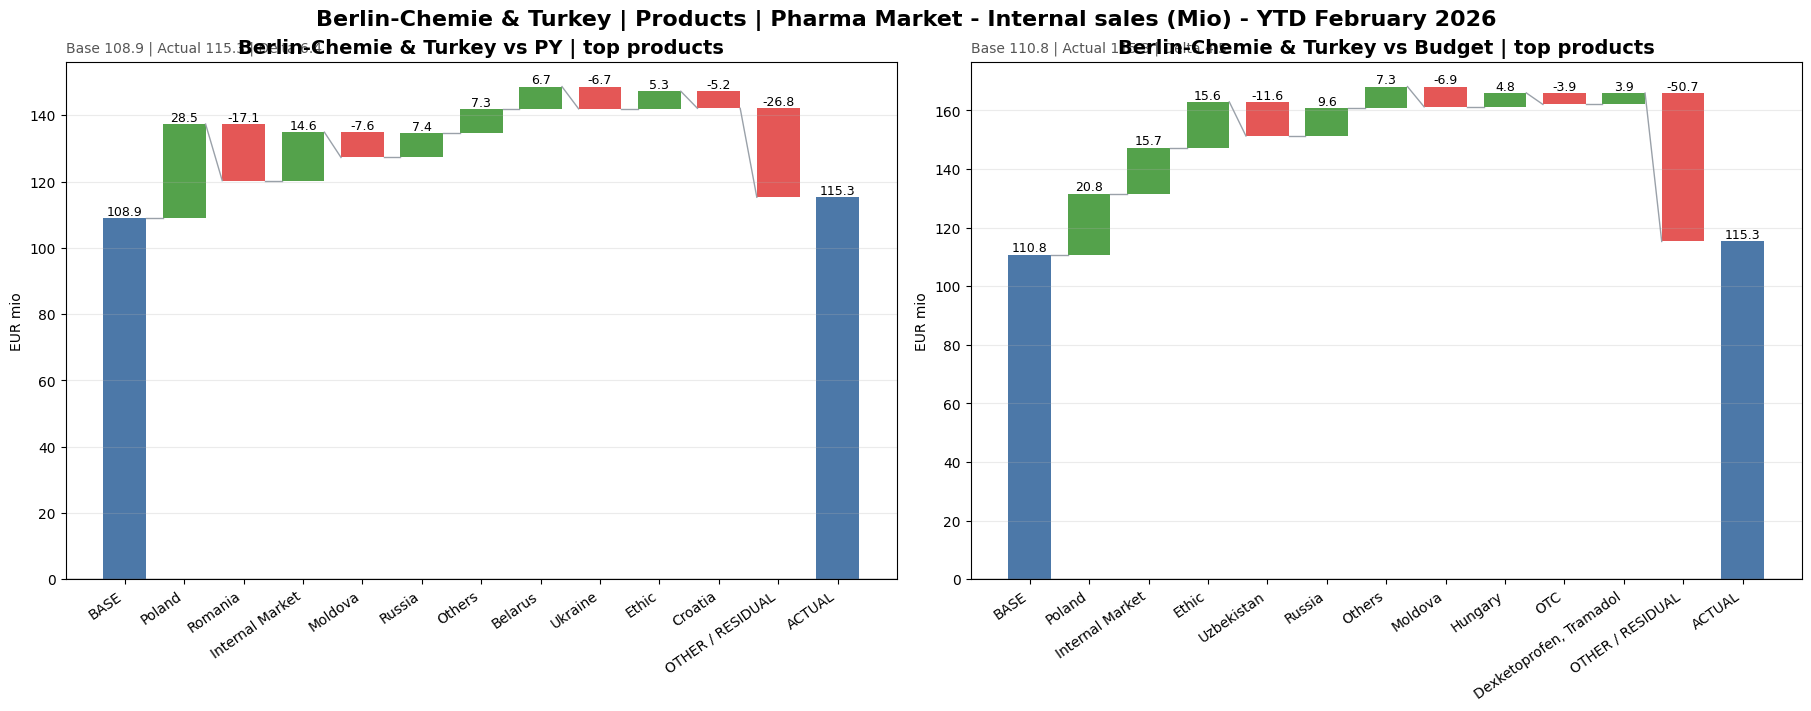

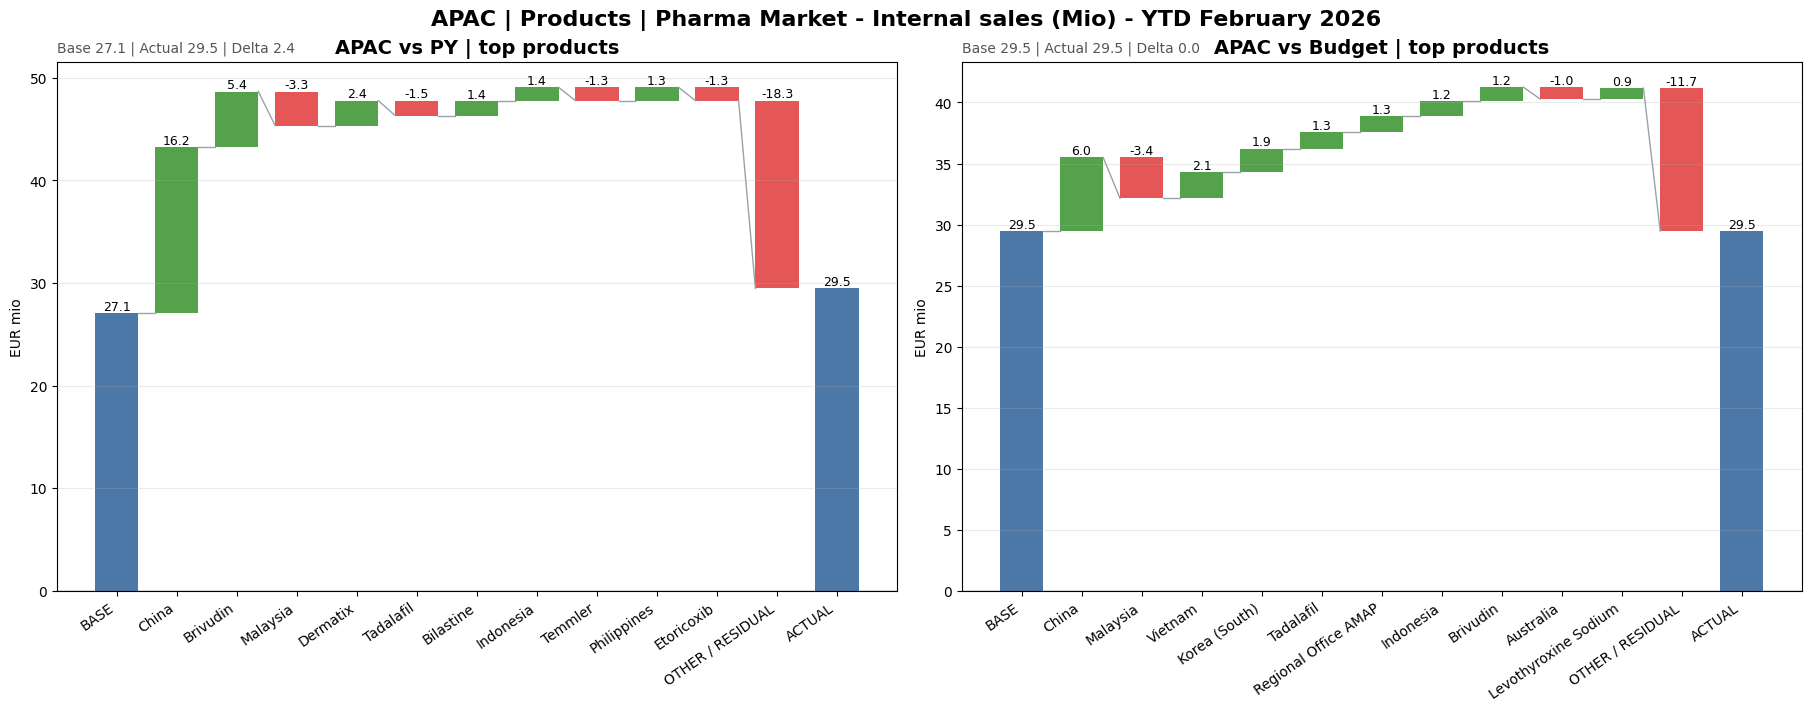

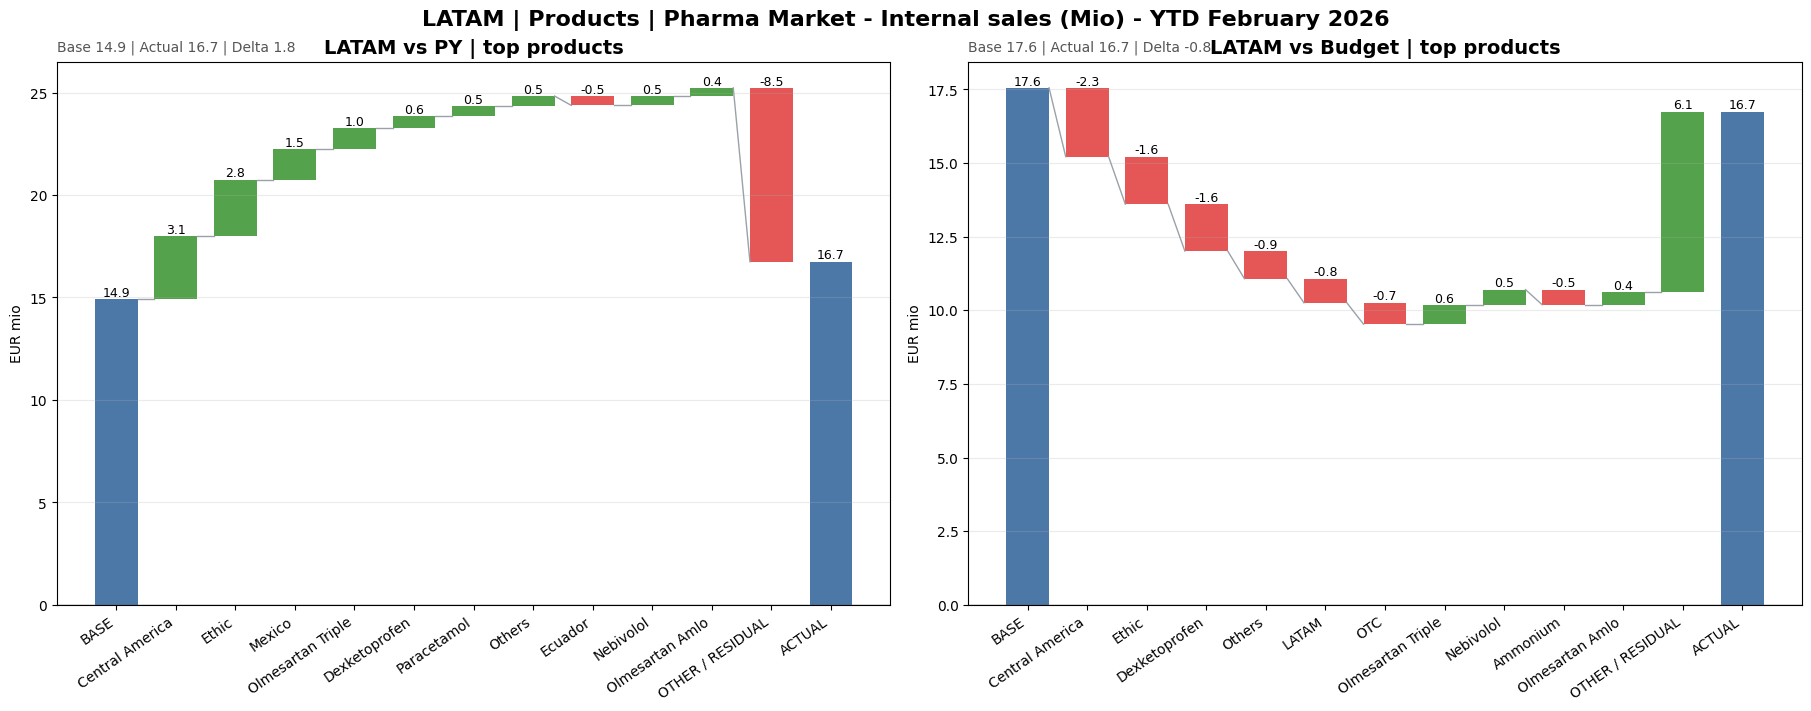

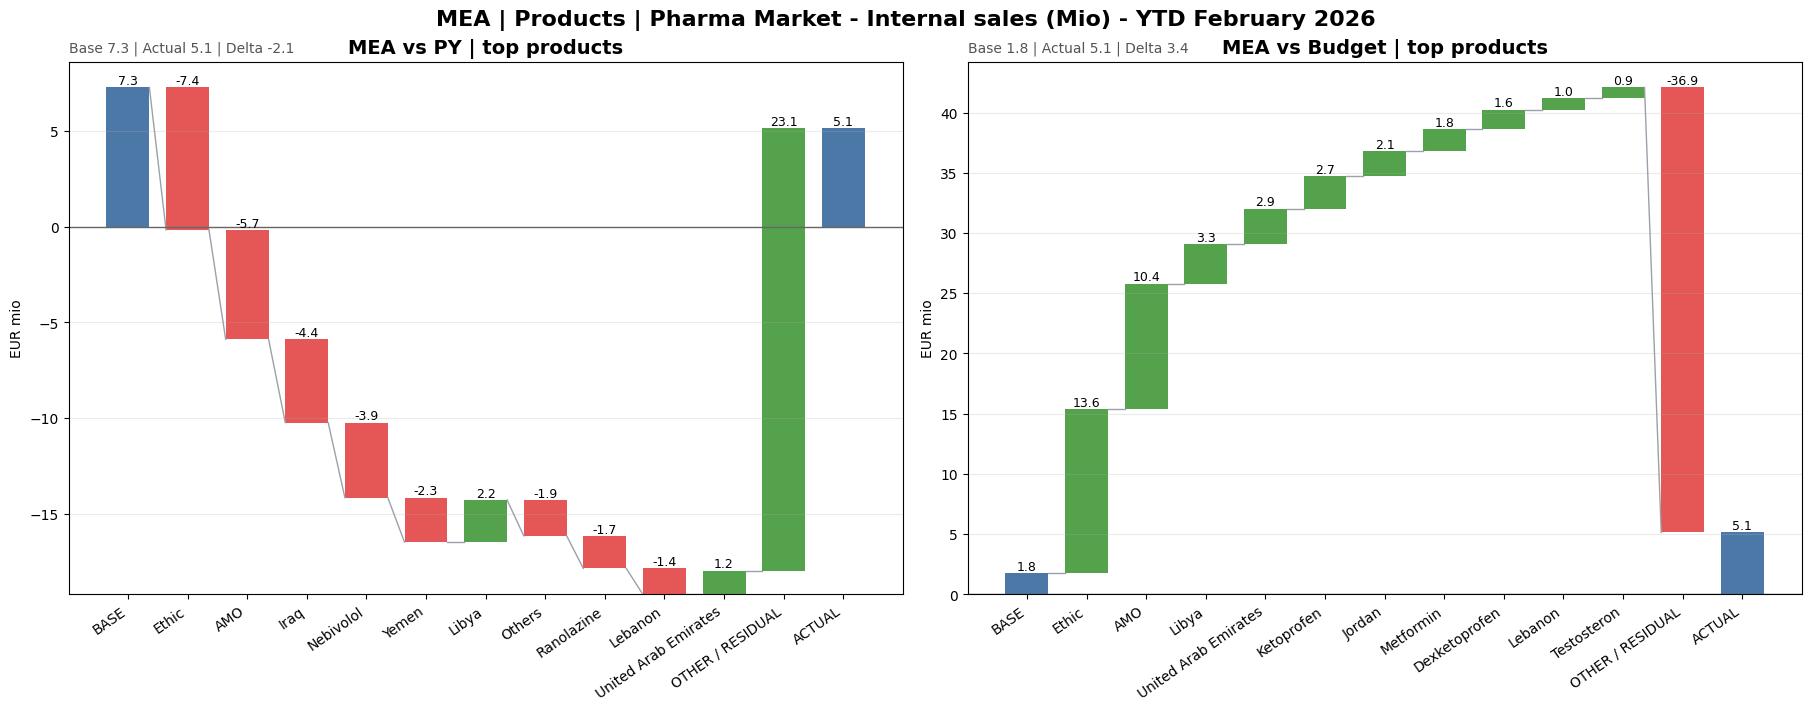

In [7]:
if area_df is None:
    print("area dataset missing for SOURCE_KIND=", SOURCE_KIND)
else:
    area_df = ensure_numeric(area_df, ["actual_value", "base_value", "variance_abs", "variance_pct"])
    cluster_title_map = {
        "WE": "WE",
        "BC_TURKEY": "Berlin-Chemie & Turkey",
        "APAC": "APAC",
        "LATAM": "LATAM",
        "MEA": "MEA",
    }

    for cluster_code, cluster_title in cluster_title_map.items():
        cluster_slice = area_df[area_df["cluster"] == cluster_code].copy()
        if cluster_slice.empty:
            continue

        fig_area = render_pair(
            cluster_slice,
            left_cfg={
                "filters": {"comparison_type": "PY"},
                "title": f"{cluster_title} vs PY | top products",
                "top_n": 10,
                "total_label_candidates": ("TOTAL",),
            },
            right_cfg={
                "filters": {"comparison_type": "BDG"},
                "title": f"{cluster_title} vs Budget | top products",
                "top_n": 10,
                "total_label_candidates": ("TOTAL",),
            },
            fig_title=f"{cluster_title} | Products | Pharma Market - Internal sales (Mio) - YTD February 2026",
        )
        maybe_export(fig_area, f"06_area_{cluster_code.lower()}_waterfall.png")
        plt.show()

## Come usare questo notebook

1. Aprilo dentro la cartella `fin_pipeline/`.
2. Lascia `SOURCE_KIND = "canonical"` per il percorso più completo.
3. Esegui `Run All`.
4. Se vuoi esportare PNG, imposta `EXPORT_FIGURES = True`.

Nota: questa è una **prima traduzione locale in waterfall** delle stesse famiglie di insight del PPT. Non è ancora una replica 1:1 del layout PowerPoint.